In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import pandas as pd
import os

In [2]:
df = pd.read_csv("../data/processed/csgo_cleaned_2.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 875112 entries, 0 to 875111
Data columns (total 40 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Unnamed: 0       875112 non-null  int64  
 1   file             875112 non-null  str    
 2   map              875112 non-null  str    
 3   date             875112 non-null  str    
 4   round            875112 non-null  int64  
 5   tick             875112 non-null  int64  
 6   seconds          875112 non-null  float64
 7   att_team         875112 non-null  str    
 8   vic_team         875112 non-null  str    
 9   att_side         875112 non-null  str    
 10  vic_side         875112 non-null  str    
 11  hp_dmg           875112 non-null  int64  
 12  arm_dmg          875112 non-null  int64  
 13  is_bomb_planted  875112 non-null  bool   
 14  bomb_site        135616 non-null  str    
 15  hitbox           875112 non-null  str    
 16  wp               875112 non-null  str    
 17  wp

In [3]:
df2 = df.drop(columns=['file', 'date', 'tick', 'seconds', 'award', 'att_id', 'vic_id', 'ct_eq_val', 't_eq_val', 'map_1'])
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 875112 entries, 0 to 875111
Data columns (total 30 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Unnamed: 0       875112 non-null  int64  
 1   map              875112 non-null  str    
 2   round            875112 non-null  int64  
 3   att_team         875112 non-null  str    
 4   vic_team         875112 non-null  str    
 5   att_side         875112 non-null  str    
 6   vic_side         875112 non-null  str    
 7   hp_dmg           875112 non-null  int64  
 8   arm_dmg          875112 non-null  int64  
 9   is_bomb_planted  875112 non-null  bool   
 10  bomb_site        135616 non-null  str    
 11  hitbox           875112 non-null  str    
 12  wp               875112 non-null  str    
 13  wp_type          875112 non-null  str    
 14  winner_team      875112 non-null  str    
 15  winner_side      875112 non-null  str    
 16  att_rank         875112 non-null  int64  
 17  vi

In [4]:
# df2["att_pos_x_scaled"] = (df2["att_pos_x"] - df2["StartX"]) / (df2["EndX"] - df2["StartX"])
# df2["att_pos_y_scaled"] = (df2["att_pos_y"] - df2["StartY"]) / (df2["EndY"] - df2["StartY"])
# df2["vic_pos_x_scaled"] = (df2["vic_pos_x"] - df2["StartX"]) / (df2["EndX"] - df2["StartX"])
# df2["vic_pos_y_scaled"] = (df2["att_pos_y"] - df2["StartY"]) / (df2["EndY"] - df2["StartY"])

# df2["vic_pos_y_scaled"].describe()

# above might not be necessary

In [5]:
import numpy as np

In [6]:
df2["inbetween_distance"] = np.sqrt(np.square(df2["att_pos_x"] - df2["vic_pos_x"]) + np.square(df2["att_pos_y"] - df2["vic_pos_y"]))
print(df2.info())
print(df2["inbetween_distance"].describe())

<class 'pandas.DataFrame'>
RangeIndex: 875112 entries, 0 to 875111
Data columns (total 31 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Unnamed: 0          875112 non-null  int64  
 1   map                 875112 non-null  str    
 2   round               875112 non-null  int64  
 3   att_team            875112 non-null  str    
 4   vic_team            875112 non-null  str    
 5   att_side            875112 non-null  str    
 6   vic_side            875112 non-null  str    
 7   hp_dmg              875112 non-null  int64  
 8   arm_dmg             875112 non-null  int64  
 9   is_bomb_planted     875112 non-null  bool   
 10  bomb_site           135616 non-null  str    
 11  hitbox              875112 non-null  str    
 12  wp                  875112 non-null  str    
 13  wp_type             875112 non-null  str    
 14  winner_team         875112 non-null  str    
 15  winner_side         875112 non-null  str    


In [7]:
# just mirage first for modeling purposes, will do all maps maybe
df2["bombsite_a_x"] = np.where(df["map"] == "de_mirage", -390, np.nan)
df2["bombsite_a_y"] = np.where(df["map"] == "de_mirage", -2090, np.nan)
df2["bombsite_b_x"] = np.where(df["map"] == "de_mirage", -2160, np.nan)
df2["bombsite_b_y"] = np.where(df["map"] == "de_mirage", -280, np.nan)
df2["bombsite_a_att_distance"] = np.sqrt(np.square(df2["att_pos_x"] - df2["bombsite_a_x"]) + np.square(df2["att_pos_y"] - df2["bombsite_a_y"]))
df2["bombsite_b_att_distance"] = np.sqrt(np.square(df2["att_pos_x"] - df2["bombsite_b_x"]) + np.square(df2["att_pos_y"] - df2["bombsite_b_y"]))
df2["bombsite_a_vic_distance"] = np.sqrt(np.square(df2["vic_pos_x"] - df2["bombsite_a_x"]) + np.square(df2["vic_pos_y"] - df2["bombsite_a_y"]))
df2["bombsite_b_vic_distance"] = np.sqrt(np.square(df2["vic_pos_x"] - df2["bombsite_b_x"]) + np.square(df2["vic_pos_y"] - df2["bombsite_b_y"]))
df2["att_distance_to_bombsite"] = np.where(df2["map"] == "de_mirage", np.minimum(df2["bombsite_a_att_distance"], df2["bombsite_b_att_distance"]), np.nan)
df2["vic_distance_to_bombsite"] = np.where(df2["map"] == "de_mirage", np.minimum(df2["bombsite_a_vic_distance"], df2["bombsite_b_vic_distance"]), np.nan)
df3 = df2.drop(columns=["bombsite_a_att_distance", "bombsite_b_att_distance", "bombsite_a_vic_distance", "bombsite_b_vic_distance",
                       "bombsite_a_x", "bombsite_a_y", "bombsite_b_x", "bombsite_b_y"])
print(df3["att_distance_to_bombsite"].describe())
print(df3["vic_distance_to_bombsite"].describe())

count    256034.000000
mean        930.452796
std         514.624375
min           1.284384
25%         531.412013
50%         906.039841
75%        1214.323940
max        3122.870253
Name: att_distance_to_bombsite, dtype: float64
count    256034.000000
mean        934.349184
std         508.062137
min           1.222473
25%         545.113037
50%         914.145997
75%        1212.346623
max        3142.344449
Name: vic_distance_to_bombsite, dtype: float64


In [8]:
df3["total_dmg"] = df3["hp_dmg"] + df3["arm_dmg"]
df3["is_headshot"] = df3["hitbox"] == "Head"
df4 = df3.drop(columns=["hp_dmg", "arm_dmg", "hitbox"])
print(df4["is_headshot"].describe())

count     875112
unique         2
top        False
freq      770854
Name: is_headshot, dtype: object


In [9]:
tier_boundaries = [0, 6, 10, 14, 18]
tiers = ["Silver", "Gold Nova", "Master Guardian", "Top Four"]

df4["att_tier"] = pd.cut(df4["att_rank"], bins=tier_boundaries, labels=tiers)
df4["vic_tier"] = pd.cut(df4["vic_rank"], bins=tier_boundaries, labels=tiers)
df5 = df4.drop(columns=["att_rank", "vic_rank"])
df5["att_tier"].describe()

count              875112
unique                  4
top       Master Guardian
freq               386287
Name: att_tier, dtype: object

In [12]:
from pandas.api.types import CategoricalDtype

custom_order = CategoricalDtype(categories=['Silver', 'Gold Nova', 'Master Guardian', 'Top Four'], ordered=True)
df5["att_tier"] = df5["att_tier"].astype(custom_order)
df5["vic_tier"] = df5["vic_tier"].astype(custom_order)

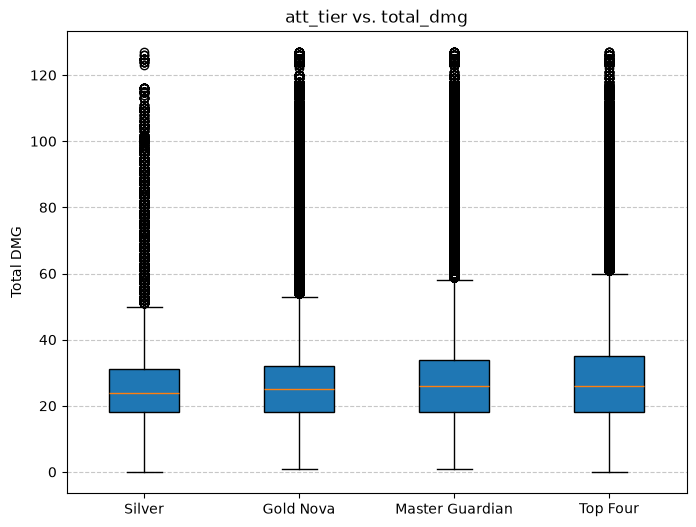

In [22]:
sorted_data = [df5.loc[df5["att_tier"] == "Silver", "total_dmg"], df5.loc[df5["att_tier"] == "Gold Nova", "total_dmg"], 
    df5.loc[df5["att_tier"] == "Master Guardian", "total_dmg"], df5.loc[df5["att_tier"] == "Top Four", "total_dmg"]]
labels = ['Silver', 'Gold Nova', 'Master Guardian', 'Top Four']

fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(sorted_data, patch_artist=True, tick_labels=labels)
ax.set_title('att_tier vs. total_dmg')
ax.set_ylabel('Total DMG')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("../images/04_total_dmg.png")
plt.show()

In [24]:
df6 = df5[df5["total_dmg"] > 0]
df6.shape

(875110, 32)

In [29]:
ct = pd.crosstab(df6["is_bomb_planted"], df6["att_tier"])
ct

att_tier,Silver,Gold Nova,Master Guardian,Top Four
is_bomb_planted,,,,
False,15299,283952,328449,111794
True,2702,55384,57838,19692


In [31]:
ct = pd.crosstab(df6["round_type"], df6["att_tier"])
ct

att_tier,Silver,Gold Nova,Master Guardian,Top Four
round_type,,,,
ECO,3332,74583,108089,40069
FORCE_BUY,3462,57148,53475,16742
NORMAL,8243,156315,168621,55416
PISTOL_ROUND,1450,27533,29843,10121
SEMI_ECO,1514,23757,26259,9138


In [35]:
ct = pd.crosstab(df6["wp"], df6["att_tier"])
ct

att_tier,Silver,Gold Nova,Master Guardian,Top Four
wp,,,,
AK47,3563,74879,96065,34662
AUG,375,4148,2285,341
AWP,453,12812,16870,6641
Bizon,341,3195,2264,459
Bomb,0,0,0,1
CZ,103,2612,4539,2097
Deagle,254,7166,10077,4523
Decoy,0,6,2,0
DualBarettas,49,805,665,124


In [41]:
print(df6["inbetween_distance"].describe())
print(df6[df6["inbetween_distance"] > 0].describe())

count    875110.000000
mean        675.436121
std         410.510692
min           0.000000
25%         363.203726
50%         610.385692
75%         917.173386
max        3816.805781
Name: inbetween_distance, dtype: float64
          Unnamed: 0          round      att_pos_x      att_pos_y  \
count  871581.000000  871581.000000  871581.000000  871581.000000   
mean      382.092524      13.525750    -257.841160     278.338171   
std       234.475257       7.861055    1147.863012    1382.310495   
min         0.000000       1.000000   -3960.000000   -3467.919000   
25%       183.000000       7.000000    -982.409400    -738.130600   
50%       369.000000      13.000000    -177.981800     290.376400   
75%       563.000000      20.000000     546.281700    1385.418000   
max      1159.000000      30.000000    3309.969000    3592.000000   

           vic_pos_x      vic_pos_y  avg_match_rank           EndX  \
count  871581.000000  871581.000000   871581.000000  871581.000000   
mean     -255

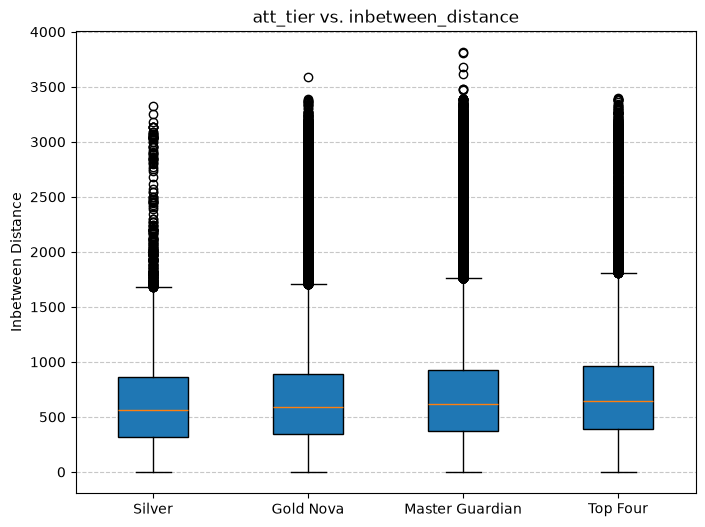

In [37]:
sorted_data = [df6.loc[df6["att_tier"] == "Silver", "inbetween_distance"], df6.loc[df6["att_tier"] == "Gold Nova", "inbetween_distance"], 
    df6.loc[df6["att_tier"] == "Master Guardian", "inbetween_distance"], df6.loc[df6["att_tier"] == "Top Four", "inbetween_distance"]]
labels = ['Silver', 'Gold Nova', 'Master Guardian', 'Top Four']

fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(sorted_data, patch_artist=True, tick_labels=labels)
ax.set_title('att_tier vs. inbetween_distance')
ax.set_ylabel('Inbetween Distance')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("../images/04_inbetween_distance.png")
plt.show()

In [27]:
folder_path = '../data/processed'
file_name = 'csgo_cleaned_3.csv'
full_path = os.path.join(folder_path, file_name)

df6.to_csv(full_path, index=False)
print(f"File successfully saved to: {full_path}")

File successfully saved to: ../data/processed\csgo_cleaned_3.csv
